In [125]:
import sympy
import numpy as np
import matplotlib.pyplot as plt
import os, sys
from scipy.stats import chi2
from matplotlib.patches import Ellipse
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
sys.path.append(os.path.abspath('..'))
from se2 import se2_exp, se2_log



In [126]:
class Model():
    def __init__(self):
        self.x = sympy.symbols('x')
        self.y = sympy.symbols('y')
        self.theta = sympy.symbols('theta')
        self.dt = sympy.symbols('dt')
        self.v_nom = sympy.symbols('v_nom')
        self.w_ref = sympy.symbols('w_ref')
        self.P = sympy.MatrixSymbol('P', 3, 3)
    
    def dynamics(self):
        x_next = self.x + self.v_nom * sympy.cos(self.theta)*self.dt
        y_next = self.y + self.v_nom * sympy.sin(self.theta)*self.dt
        theta_next = self.theta + self.w_ref * self.dt
        return sympy.Matrix([x_next, y_next, theta_next])

    def state(self):
        return sympy.Matrix([self.x, self.y, self.theta])
    
    def Jacobian(self):
        return self.dynamics().jacobian(self.state())

    def Q_body(self):
        sigma_v, sigma_w = sympy.symbols('sigma_v sigma_w')
        return sympy.diag(sigma_v**2, 0, sigma_w**2)
    
    def Q(self):
        Lk = self.dt * sympy.Matrix([
            [sympy.cos(self.theta), 0, 0],
            [sympy.sin(self.theta), 0, 0],
            [0,                     0, 1]
        ])
        return Lk * self.Q_body() * Lk.T

    def measurement_noise(self):
        sigma_gps = sympy.symbols('sigma_gps')
        R = sigma_gps**2 * sympy.eye(2)
        return R

    def measurement_jacobian(self):
        return sympy.Matrix([self.x, self.y]).jacobian(self.state())



In [127]:
class KF():
    def __init__(self, model):
        syms = [model.x, model.y, model.theta, model.v_nom, model.w_ref, model.dt]
        noise_syms = sympy.symbols('sigma_v sigma_w sigma_gps')

        self.f = sympy.lambdify(syms, model.dynamics(), 'numpy')
        self.F = sympy.lambdify(syms, model.Jacobian(), 'numpy')
        self.Q = sympy.lambdify([model.theta, model.dt, noise_syms[0], noise_syms[1]], model.Q(), 'numpy')
        self.H = np.array(model.measurement_jacobian()).astype(float)
        self.R = sympy.lambdify([noise_syms[2]], model.measurement_noise(), 'numpy')

    def predict(self, x_est, P_est, v, w, dt, sigma_v, sigma_w):
        x_pred = np.array(self.f(*x_est, v, w, dt)).flatten()
        F_val = np.array(self.F(*x_est, v, w, dt)).astype(float)
        Q_val = np.array(self.Q(x_est[2], dt, sigma_v, sigma_w)).astype(float)
        P_pred = F_val @ P_est @ F_val.T + Q_val
        return x_pred, P_pred

    def update(self, x_pred, P_pred, z, sigma_gps):
        H = self.H
        R = np.array(self.R(sigma_gps)).astype(float)
        K = P_pred @ H.T @ np.linalg.inv(H @ P_pred @ H.T + R)
        x_est = x_pred + K @ (z - H @ x_pred)
        P_est = (np.eye(3) - K @ H) @ P_pred @ (np.eye(3) - K @ H).T + K @ R @ K.T
        return x_est, P_est

    def simulate_step(self, x_est, P_est, z, v, w, dt, sigma_v, sigma_w, sigma_gps):
        x_pred, P_pred = self.predict(x_est, P_est, v, w, dt, sigma_v, sigma_w)
        x_est, P_est = self.update(x_pred, P_pred, z, sigma_gps)
        return x_est, P_est
    

In [128]:
# Model
model = Model()
model.dynamics()
kf = KF(model)
rng = np.random.default_rng(67676767)


In [129]:
model.measurement_jacobian()

Matrix([
[1, 0, 0],
[0, 1, 0]])

In [130]:
# Constants
pi = np.pi

# Parameters
v_nom = 2
w_turn = 0.4
r_fig = 5
sigma_v = 1.0
sigma_w = 0.05
sigma_gps = 0.3
dt = 0.1

# Simulation parameters
T_lobe = 2 * pi / w_turn
T_fig8 = 10 * pi
T = 35
n_steps = int(T / dt)
gps_freq = 1

# Initial conditions
x0_true = np.array([0.0, 0.0, 0.0])
x0_est = np.array([0.0, 0.0, 0.0])
P0 = np.diag([0.01, 0.01, 0.01])
H = kf.H
R = np.array(kf.R(sigma_gps)).astype(float)

In [131]:
x_true_hist = np.zeros((n_steps + 1, 3))
x_est_hist  = np.zeros((n_steps + 1, 3))
P_est_hist  = np.zeros((n_steps + 1, 3, 3))
z_hist      = np.full((n_steps, 2), np.nan)

x_true_hist[0] = x0_true
x_est_hist[0]  = x0_est
P_est_hist[0]  = P0

X_true = np.eye(3)
x_est = x0_est.copy()
P_est = P0.copy()
for i in range(n_steps):
    t = i * dt
    if t % T_fig8 < T_lobe:
        w_ref = w_turn
    else:
        w_ref = -w_turn

    # Noise
    n_v = sigma_v * rng.standard_normal()
    n_w = sigma_w * rng.standard_normal()

    # True state (SE(2) Lie group propagation)
    xi = np.array([v_nom + n_v, 0, w_ref + n_w]) * dt
    X_true = X_true @ se2_exp(xi)
    x_true = np.array([X_true[0, 2], X_true[1, 2], np.arctan2(X_true[1, 0], X_true[0, 0])])

    
    # EKF
    x_est, P_est = kf.predict(x_est, P_est, v_nom, w_ref, dt, sigma_v, sigma_w)
    if t % (1 / gps_freq) < 0.01:
        z = H @ x_true + rng.multivariate_normal(np.zeros(2), R)
        x_est, P_est = kf.update(x_est, P_est, z, sigma_gps)
        z_hist[i] = z

    x_true_hist[i + 1] = x_true
    x_est_hist[i + 1]  = x_est
    P_est_hist[i + 1]  = P_est

In [132]:
def cov_ellipse(P_2x2, center, n_std=3.0):
    eigvals, eigvecs = np.linalg.eigh(P_2x2)
    order = eigvals.argsort()[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]
    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
    w, h = 2 * n_std * np.sqrt(eigvals)
    return Ellipse(xy=center, width=w, height=h, angle=angle,
                   fill=False, edgecolor='red', linewidth=1.5)

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect('equal')
ax.grid(True)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('EKF Animation')

true_line, = ax.plot([], [], 'k-', linewidth=0.8, label='True')
est_line, = ax.plot([], [], 'b--', linewidth=1.2, label='EKF Estimate')
gps_scatter = ax.scatter([], [], c='green', s=15, marker='x', label='GPS', zorder=5, alpha=0.5)
ellipse_patch = None
ax.legend(loc='upper left')

pad = 2
ax.set_xlim(x_true_hist[:, 0].min() - pad, x_true_hist[:, 0].max() + pad)
ax.set_ylim(x_true_hist[:, 1].min() - pad, x_true_hist[:, 1].max() + pad)

skip = 5

def init():
    true_line.set_data([], [])
    est_line.set_data([], [])
    gps_scatter.set_offsets(np.empty((0, 2)))
    return true_line, est_line, gps_scatter

def animate(frame):
    global ellipse_patch
    k = frame * skip
    
    true_line.set_data(x_true_hist[:k+1, 0], x_true_hist[:k+1, 1])
    est_line.set_data(x_est_hist[:k+1, 0], x_est_hist[:k+1, 1])

    z_slice = z_hist[:k]
    gps_mask = ~np.isnan(z_slice[:, 0])
    if gps_mask.any():
        gps_scatter.set_offsets(z_slice[gps_mask])

    if ellipse_patch is not None:
        ellipse_patch.remove()
    P_k = P_est_hist[k]
    ellipse_patch = cov_ellipse(P_k[:2, :2], x_est_hist[k, :2])
    ax.add_patch(ellipse_patch)

    return true_line, est_line, gps_scatter, ellipse_patch

n_frames = (n_steps + 1) // skip
anim = FuncAnimation(fig, animate, init_func=init, frames=n_frames, interval=30, blit=False)
anim.save('ekf_animation.gif', writer='pillow', fps=30)
plt.close(fig)
print('Saved ekf_animation.gif')
HTML(anim.to_jshtml())

Saved ekf_animation.gif


In [133]:
N = 100 # Monte Carlo samples

epsilon_all = np.zeros((N, n_steps)) 
nu_all = np.full((N, n_steps), np.nan)

for j in range(N):
    X_true = np.eye(3)
    x_est  = x0_est.copy()
    P_est  = P0.copy()
    
    for i in range(n_steps):
        t = i * dt
        if t % T_fig8 < T_lobe:
            w_ref = w_turn
        else:
            w_ref = -w_turn

        # Noise
        n_v = sigma_v * np.random.standard_normal()
        n_w = sigma_w * np.random.standard_normal()

        # True state (SE(2) Lie group propagation)
        xi = np.array([v_nom + n_v, 0, w_ref + n_w]) * dt
        X_true = X_true @ se2_exp(xi)
        x_true = np.array([X_true[0, 2], X_true[1, 2], np.arctan2(X_true[1, 0], X_true[0, 0])])

        # EKF
        x_est, P_est = kf.predict(x_est, P_est, v_nom, w_ref, dt, sigma_v, sigma_w)
        if t % (1 / gps_freq) < 0.01:
            S = H @ P_est @ H.T + R
            z = H @ x_true + np.random.multivariate_normal(np.zeros(2), R)
            innov = z - H @ x_est
            nu_all[j, i] = innov.T @ np.linalg.inv(S) @ innov
            x_est, P_est = kf.update(x_est, P_est, z, sigma_gps)
        else:
            nu_all[j, i] = None

        delta_x = x_true - x_est
        delta_x[2] = (delta_x[2] + np.pi) % (2 * np.pi) - np.pi 
        epsilon_all[j, i] = delta_x.T @ np.linalg.inv(P_est) @ delta_x


epsilon_bar = np.mean(epsilon_all, axis=0)
nu_bar = np.nanmean(nu_all, axis=0)   


C:\Users\Yahor\AppData\Local\Temp\ipykernel_38008\1591604244.py:44: RuntimeWarning: Mean of empty slice
  nu_bar = np.nanmean(nu_all, axis=0)


In [134]:
nx = 3
nz = 2

# NEES band
nees_lo = chi2.ppf(0.025, df=N*nx) / N
nees_hi = chi2.ppf(0.975, df=N*nx) / N

# NIS band
nis_lo = chi2.ppf(0.025, df=N*nz) / N
nis_hi = chi2.ppf(0.975, df=N*nz) / N

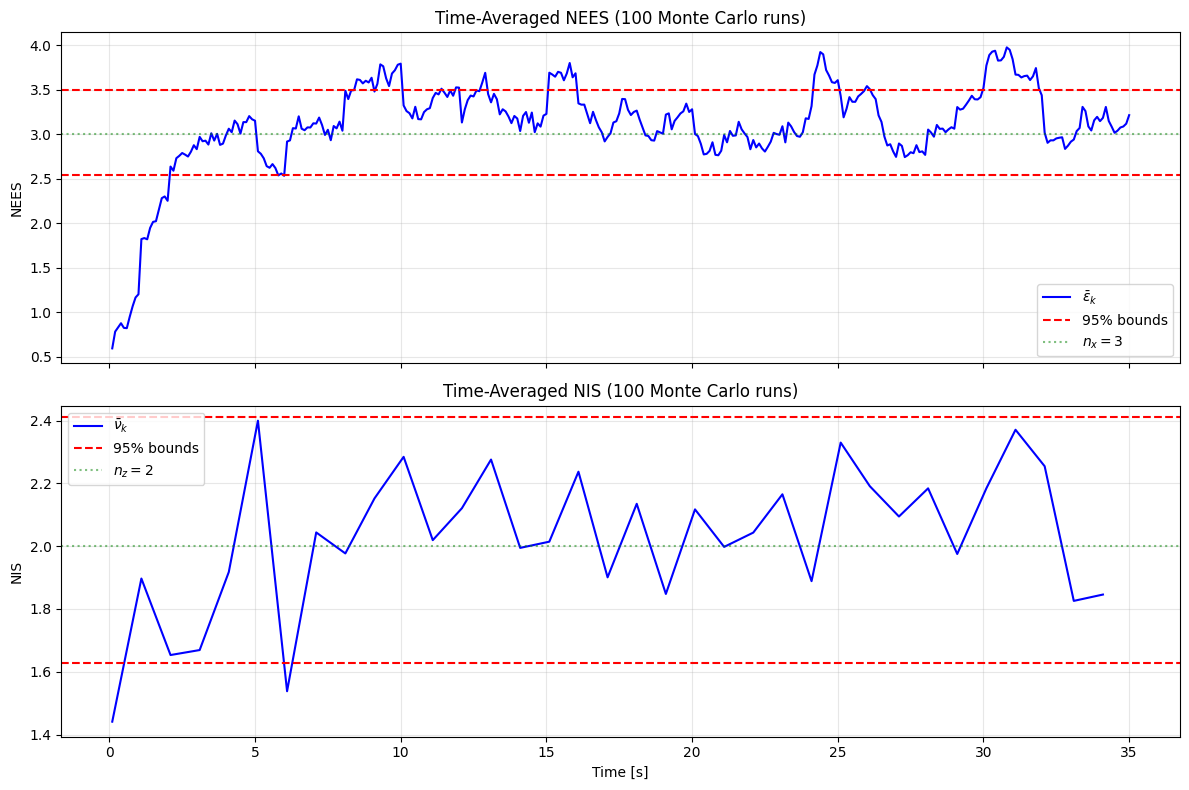

In [135]:
t_vec = np.arange(1, n_steps + 1) * dt

gps_mask = ~np.isnan(nu_bar)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(t_vec, epsilon_bar, color='b', linewidth=1.5, label=r'$\bar{\epsilon}_k$')
ax1.axhline(nees_lo, color='r', linestyle='--', label='95% bounds')
ax1.axhline(nees_hi, color='r', linestyle='--')
ax1.axhline(nx, color='g', linestyle=':', alpha=0.5, label=r'$n_x = 3$')
ax1.set_ylabel('NEES')
ax1.set_title(f'Time-Averaged NEES ({N} Monte Carlo runs)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(t_vec[gps_mask], nu_bar[gps_mask], color='b', linewidth=1.5, label=r'$\bar{\nu}_k$')
ax2.axhline(nis_lo, color='r', linestyle='--', label='95% bounds')
ax2.axhline(nis_hi, color='r', linestyle='--')
ax2.axhline(nz, color='g', linestyle=':', alpha=0.5, label=r'$n_z = 2$')
ax2.set_ylabel('NIS')
ax2.set_xlabel('Time [s]')
ax2.set_title(f'Time-Averaged NIS ({N} Monte Carlo runs)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('NEES_NIS_EKF.png', dpi=150)
plt.show()